# Dual-Path Fake News Classifier — Improved Pipeline

**Problem from previous run:**
- Path A (Stack): Fake recall = 84% (52 missed fakes)
- Path B (BERT): Fake recall = 69.1% (100 missed fakes) ← frozen embeddings are the culprit

**Fixes in this version:**

| Issue | Fix |
|-------|-----|
| Frozen BERT embeddings too weak | Fine-tune full BERT with classification head |
| Stack missing fakes | Lower threshold + higher recall-weighted loss |
| SVM slow on large SMOTE data | Switch to LinearSVC (10x faster, same quality) |
| Threshold search range too narrow | Extend to 0.10–0.60 for recall-focused tuning |
| Evaluation metric only macro F1 | Add recall-weighted F1 as tiebreaker |

```
Input text
  ├── PATH A → TF-IDF → LR + RF + LinearSVC → Meta LR → threshold → Output A
  └── PATH B → Fine-tuned BERT (full)        → threshold           → Output B
```

---
# 1. Install Dependencies

In [1]:
!pip install -q transformers torch scikit-learn imbalanced-learn pandas numpy tqdm matplotlib seaborn

# 2. Imports

In [3]:
# ===================== BASIC LIBRARIES =====================
import re, os, zipfile, warnings
import numpy as np
import pandas as pd

# ===================== TORCH =====================
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR

# ===================== VISUALIZATION =====================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings('ignore')

# ===================== UTILITIES =====================
from tqdm import tqdm

# ===================== SKLEARN =====================
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

# Calibration (IMPORTANT)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# Metrics (FIXED)
from sklearn.metrics import (
    classification_report, f1_score, accuracy_score,
    confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score,
    matthews_corrcoef, cohen_kappa_score,
    brier_score_loss,
    log_loss, roc_auc_score
)

# ===================== IMBALANCE =====================
from imblearn.over_sampling import SMOTE

# ===================== TRANSFORMERS =====================
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

# ===================== DEVICE =====================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

# ===================== DARK THEME =====================
plt.rcParams.update({
    'figure.facecolor' : '#0D1117',
    'axes.facecolor'   : '#161B22',
    'axes.edgecolor'   : '#30363D',
    'axes.labelcolor'  : '#C9D1D9',
    'axes.titlecolor'  : '#F0F6FC',
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
    'axes.grid'        : True,
    'grid.color'       : '#21262D',
    'grid.linewidth'   : 0.6,
    'xtick.color'      : '#8B949E',
    'ytick.color'      : '#8B949E',
    'text.color'       : '#C9D1D9',
    'legend.facecolor' : '#161B22',
    'legend.edgecolor' : '#30363D',
    'legend.fontsize'  : 10,
    'font.family'      : 'DejaVu Sans',
    'figure.dpi'       : 140,
    'savefig.dpi'      : 180,
    'savefig.facecolor': '#0D1117',
})

# ===================== COLORS =====================
C_STACK  = '#58A6FF'
C_BERT   = '#3FB950'
C_CHANCE = '#6E7681'
C_FAKE   = '#F85149'
C_REAL   = '#58A6FF'

LABELS = ['Real', 'Fake']

print('✅ Imports OK. No errors now.')

Device: cuda
✅ Imports OK. No errors now.


---
# 3. Load & Split Dataset

In [6]:
df = pd.read_csv('fake_news_final_dataset (1).csv')
df = df[df['final_text'].notna() & (df['final_text'].str.strip() != '')].reset_index(drop=True)

X = df['final_text'].astype(str).tolist()
y = df['label'].tolist()

print(f'Total rows      : {len(df)}')
print(f'Fake (1)        : {sum(y)}')
print(f'Real (0)        : {len(y)-sum(y)}')
print(f'Imbalance ratio : 1 : {(len(y)-sum(y))/sum(y):.1f}')

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

y_train = np.array(y_train)
y_val   = np.array(y_val)
y_test  = np.array(y_test)

print(f'\nTrain: {len(X_train)}  |  Val: {len(X_val)}  |  Test: {len(X_test)}')
print(f'Train fake/real: {y_train.sum()} / {(y_train==0).sum()}')

Total rows      : 23195
Fake (1)        : 5754
Real (0)        : 17441
Imbalance ratio : 1 : 3.0

Train: 16236  |  Val: 3479  |  Test: 3480
Train fake/real: 4028 / 12208


---
# PATH A — Improved Stacked Classifier
## A1. TF-IDF + SMOTE

In [7]:
tfidf = TfidfVectorizer(max_features=100000, ngram_range=(1, 3),
                        sublinear_tf=True, min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_tfidf, y_train)
print(f'TF-IDF shape  : {X_train_tfidf.shape}')
print(f'After SMOTE   : fake={y_train_sm.sum()}  real={(y_train_sm==0).sum()}')

TF-IDF shape  : (16236, 100000)
After SMOTE   : fake=12208  real=12208


## A2. Base Models

In [8]:
# Logistic Regression — higher C for less regularisation
lr = LogisticRegression(max_iter=2000, C=10.0, class_weight='balanced',
                        solver='lbfgs', n_jobs=-1)
lr.fit(X_train_sm, y_train_sm)
lr_val_prob  = lr.predict_proba(X_val_tfidf)[:, 1]
lr_test_prob = lr.predict_proba(X_test_tfidf)[:, 1]
print('LR  accuracy:', accuracy_score(y_test, lr.predict(X_test_tfidf)))

# Random Forest — more trees, min_samples_leaf to reduce overfitting
rf = RandomForestClassifier(n_estimators=500, class_weight='balanced_subsample',
                            min_samples_leaf=2, n_jobs=-1, random_state=42)
rf.fit(X_train_sm, y_train_sm)
rf_val_prob  = rf.predict_proba(X_val_tfidf)[:, 1]
rf_test_prob = rf.predict_proba(X_test_tfidf)[:, 1]
print('RF  accuracy:', accuracy_score(y_test, rf.predict(X_test_tfidf)))

# LinearSVC + Platt scaling (replaces slow kernel SVM, same quality)
svc_raw = LinearSVC(C=0.5, class_weight='balanced', max_iter=5000)
svm = CalibratedClassifierCV(svc_raw, cv=3)
svm.fit(X_train_sm, y_train_sm)
svm_val_prob  = svm.predict_proba(X_val_tfidf)[:, 1]
svm_test_prob = svm.predict_proba(X_test_tfidf)[:, 1]
print('SVM accuracy:', accuracy_score(y_test, svm.predict(X_test_tfidf)))

LR  accuracy: 0.9091954022988505
RF  accuracy: 0.8778735632183908
SVM accuracy: 0.9132183908045977


## A3. Meta-Learner

In [9]:
X_meta_val  = np.column_stack([lr_val_prob,  rf_val_prob,  svm_val_prob])
X_meta_test = np.column_stack([lr_test_prob, rf_test_prob, svm_test_prob])

# class_weight gives more penalty for missing fakes
meta_stack = LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced')
meta_stack.fit(X_meta_val, y_val)

stack_prob     = meta_stack.predict_proba(X_meta_test)[:, 1]
stack_val_prob = meta_stack.predict_proba(X_meta_val)[:, 1]

## A4. Threshold Tuning — Recall-Weighted

In [10]:
# Score = 0.4 * macro_f1 + 0.6 * fake_recall  (penalise missing fakes more)
best_thresh_a, best_score_a = 0.5, 0.0
for t in np.arange(0.10, 0.65, 0.01):
    preds = (stack_val_prob >= t).astype(int)
    macro = f1_score(y_val, preds, average='macro', zero_division=0)
    fake_rec = f1_score(y_val, preds, pos_label=1, average='binary', zero_division=0)
    score = 0.4 * macro + 0.6 * fake_rec
    if score > best_score_a:
        best_score_a, best_thresh_a = score, t

stack_pred = (stack_prob >= best_thresh_a).astype(int)

print(f'Best threshold (Path A): {best_thresh_a:.2f}')
print('='*52)
print('OUTPUT A — Stacked Model (LR + RF + LinearSVC)')
print('='*52)
print(classification_report(y_test, stack_pred, target_names=['Real','Fake'], digits=4))

Best threshold (Path A): 0.64
OUTPUT A — Stacked Model (LR + RF + LinearSVC)
              precision    recall  f1-score   support

        Real     0.9612    0.9182    0.9392      2617
        Fake     0.7816    0.8876    0.8313       863

    accuracy                         0.9106      3480
   macro avg     0.8714    0.9029    0.8852      3480
weighted avg     0.9167    0.9106    0.9124      3480



---
# PATH B — Fine-Tuned BERT
## B1. Dataset & DataLoader

In [11]:
BERT_MODEL = 'bert-base-uncased'
MAX_LEN    = 256
BATCH_SIZE = 16          # fine-tuning needs smaller batches
EPOCHS     = 4
LR_BERT    = 2e-5

tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)


class NewsDataset(Dataset):
    def __init__(self, texts, labels=None):
        self.texts  = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx],
            truncation=True, padding='max_length',
            max_length=MAX_LEN, return_tensors='pt'
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


# Compute class weights for weighted cross-entropy
n_real = (y_train == 0).sum()
n_fake = (y_train == 1).sum()
w_real = len(y_train) / (2 * n_real)
w_fake = len(y_train) / (2 * n_fake)
class_weights = torch.tensor([w_real, w_fake], dtype=torch.float).to(DEVICE)
print(f'Class weights → real: {w_real:.3f}  fake: {w_fake:.3f}')

train_ds = NewsDataset(X_train, y_train.tolist())
val_ds   = NewsDataset(X_val,   y_val.tolist())
test_ds  = NewsDataset(X_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32,         shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32,         shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Class weights → real: 0.665  fake: 2.015
Train batches: 1015  |  Val batches: 109


## B2. Fine-Tune BERT (full model)

In [12]:
bert_model = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL, num_labels=2
).to(DEVICE)

optimizer = AdamW(bert_model.parameters(), lr=LR_BERT, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)
loss_fn = nn.CrossEntropyLoss(weight=class_weights)


def evaluate_bert(loader):
    bert_model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            ids  = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            logits = bert_model(input_ids=ids, attention_mask=mask).logits
            probs  = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            all_probs.extend(probs)
            if 'labels' in batch:
                all_labels.extend(batch['labels'].numpy())
    return np.array(all_probs), np.array(all_labels) if all_labels else None


best_val_f1 = 0.0
best_bert_state = None

for epoch in range(EPOCHS):
    bert_model.train()
    total_loss = 0
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}')

    for batch in pbar:
        ids    = batch['input_ids'].to(DEVICE)
        mask   = batch['attention_mask'].to(DEVICE)
        labels = batch['labels'].to(DEVICE)

        optimizer.zero_grad()
        logits = bert_model(input_ids=ids, attention_mask=mask).logits
        loss   = loss_fn(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    # Validation
    val_probs, val_labels = evaluate_bert(val_loader)

    # Find best threshold on val
    best_t, best_f = 0.5, 0.0
    for t in np.arange(0.10, 0.65, 0.01):
        preds = (val_probs >= t).astype(int)
        macro   = f1_score(val_labels, preds, average='macro', zero_division=0)
        fake_f1 = f1_score(val_labels, preds, pos_label=1, zero_division=0)
        score   = 0.4 * macro + 0.6 * fake_f1
        if score > best_f:
            best_f, best_t = score, t

    val_preds = (val_probs >= best_t).astype(int)
    val_f1    = f1_score(val_labels, val_preds, average='macro')
    val_fake  = f1_score(val_labels, val_preds, pos_label=1)

    print(f'  Epoch {epoch+1} | loss={total_loss/len(train_loader):.4f} '
          f'| val macro-F1={val_f1:.4f} | fake-F1={val_fake:.4f} | thresh={best_t:.2f}')

    if val_f1 > best_val_f1:
        best_val_f1   = val_f1
        best_thresh_b = best_t
        best_bert_state = {k: v.clone() for k, v in bert_model.state_dict().items()}
        print(f'  ✓ New best model saved (val macro-F1={best_val_f1:.4f})')

print(f'\nBest val macro-F1: {best_val_f1:.4f}  |  Best threshold: {best_thresh_b:.2f}')

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Epoch 1/4: 100%|██████████| 1015/1015

  Epoch 1 | loss=0.3131 | val macro-F1=0.8759 | fake-F1=0.8184 | thresh=0.64
  ✓ New best model saved (val macro-F1=0.8759)


Epoch 2/4: 100%|██████████| 1015/1015 [12:10<00:00,  1.39it/s, loss=0.0539]


  Epoch 2 | loss=0.1872 | val macro-F1=0.8920 | fake-F1=0.8396 | thresh=0.48
  ✓ New best model saved (val macro-F1=0.8920)


Epoch 3/4: 100%|██████████| 1015/1015 [12:12<00:00,  1.39it/s, loss=0.0012]


  Epoch 3 | loss=0.1048 | val macro-F1=0.8908 | fake-F1=0.8399 | thresh=0.10


Epoch 4/4: 100%|██████████| 1015/1015 [12:11<00:00,  1.39it/s, loss=0.3105]


  Epoch 4 | loss=0.0473 | val macro-F1=0.8924 | fake-F1=0.8414 | thresh=0.51
  ✓ New best model saved (val macro-F1=0.8924)

Best val macro-F1: 0.8924  |  Best threshold: 0.51


## B3. Evaluate Best BERT on Test Set

In [13]:
# Load best checkpoint
bert_model.load_state_dict(best_bert_state)

bert_prob, _       = evaluate_bert(test_loader)
bert_val_prob, _   = evaluate_bert(val_loader)
bert_pred          = (bert_prob >= best_thresh_b).astype(int)

print(f'Best threshold (Path B): {best_thresh_b:.2f}')
print('='*52)
print('OUTPUT B — Fine-Tuned BERT')
print('='*52)
print(classification_report(y_test, bert_pred, target_names=['Real','Fake'], digits=4))

Best threshold (Path B): 0.51
OUTPUT B — Fine-Tuned BERT
              precision    recall  f1-score   support

        Real     0.9619    0.9358    0.9487      2617
        Fake     0.8201    0.8876    0.8525       863

    accuracy                         0.9239      3480
   macro avg     0.8910    0.9117    0.9006      3480
weighted avg     0.9267    0.9239    0.9248      3480



---
# 5. Quick Comparison Table

In [14]:
def quick_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        'Accuracy'   : f'{accuracy_score(y_true, y_pred)*100:.2f}%',
        'Macro F1'   : f'{f1_score(y_true, y_pred, average="macro")*100:.2f}%',
        'Fake Recall': f'{tp/max(tp+fn,1)*100:.2f}%',
        'Fake F1'    : f'{f1_score(y_true, y_pred, pos_label=1)*100:.2f}%',
        'Real F1'    : f'{f1_score(y_true, y_pred, pos_label=0)*100:.2f}%',
    }

results = pd.DataFrame([
    {'Model': 'LR  (base)',  **quick_metrics(y_test, lr.predict(X_test_tfidf))},
    {'Model': 'RF  (base)',  **quick_metrics(y_test, rf.predict(X_test_tfidf))},
    {'Model': 'SVM (base)',  **quick_metrics(y_test, svm.predict(X_test_tfidf))},
    {'Model': 'Stack  (A)', **quick_metrics(y_test, stack_pred)},
    {'Model': 'BERT   (B)', **quick_metrics(y_test, bert_pred)},
])
print(results.to_string(index=False))

     Model Accuracy Macro F1 Fake Recall Fake F1 Real F1
LR  (base)   90.92%   88.44%      89.92%  83.08%  93.79%
RF  (base)   87.79%   85.43%      95.83%  79.56%  91.29%
SVM (base)   91.32%   88.27%      81.34%  82.30%  94.25%
Stack  (A)   91.06%   88.52%      88.76%  83.13%  93.92%
BERT   (B)   92.39%   90.06%      88.76%  85.25%  94.87%


---
# 6. Save Models

In [15]:
import joblib
joblib.dump(tfidf,      'tfidf_vectorizer.pkl')
joblib.dump(lr,         'model_lr.pkl')
joblib.dump(rf,         'model_rf.pkl')
joblib.dump(svm,        'model_svm.pkl')
joblib.dump(meta_stack, 'model_meta_stack.pkl')
joblib.dump({'thresh_a': best_thresh_a, 'thresh_b': best_thresh_b}, 'thresholds.pkl')
bert_model.save_pretrained('bert_finetuned')
tokenizer.save_pretrained('bert_finetuned')
print('All models saved.')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

All models saved.


---
# 7. Evaluation Metrics
## 7.1 Helper Functions

In [16]:
def plot_confusion(ax, y_true, y_pred, title, color):
    cm = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    annot = np.array([[f'{cm[i,j]}\n({cm_pct[i,j]:.1f}%)' for j in range(2)] for i in range(2)])
    cmap = LinearSegmentedColormap.from_list('cm', ['#161B22', color], N=256)
    sns.heatmap(cm_pct, annot=annot, fmt='', cmap=cmap,
                linewidths=1.5, linecolor='#0D1117',
                xticklabels=LABELS, yticklabels=LABELS, ax=ax,
                vmin=0, vmax=100,
                annot_kws={'size':12,'weight':'bold','color':'#F0F6FC'},
                cbar_kws={'shrink':0.75,'pad':0.02})
    ax.set_title(title, pad=14, fontsize=13, color='#F0F6FC', fontweight='bold')
    ax.set_ylabel('True label', labelpad=10)
    ax.set_xlabel('Predicted label', labelpad=10)
    ax.tick_params(colors='#8B949E', length=0)
    ax.collections[0].colorbar.ax.tick_params(colors='#8B949E')
    ax.collections[0].colorbar.set_label('% of true class', color='#8B949E', fontsize=9)
    for i in range(2):
        ax.add_patch(plt.Rectangle((i,i),1,1,fill=False,edgecolor='#F0F6FC',lw=2,zorder=5))


def threshold_sweep(y_true, probs, color, title, ax):
    thresholds = np.arange(0.05, 0.96, 0.01)
    f1s, precs, recs, accs = [], [], [], []
    for t in thresholds:
        p = (probs >= t).astype(int)
        f1s.append(f1_score(y_true,p,average='macro',zero_division=0))
        precs.append(f1_score(y_true,p,pos_label=1,average='binary',zero_division=0))
        recs.append(sum((p==1)&(y_true==1))/max(sum(y_true==1),1))
        accs.append(accuracy_score(y_true,p))
    best_t = thresholds[np.argmax(f1s)]
    ax.plot(thresholds,f1s,  color=color,   lw=2,   label='Macro F1')
    ax.plot(thresholds,precs,color='#F85149',lw=1.5,ls='--',label='Fake Precision')
    ax.plot(thresholds,recs, color='#E3B341',lw=1.5,ls='--',label='Fake Recall')
    ax.plot(thresholds,accs, color='#8B949E',lw=1.2,ls=':' ,label='Accuracy')
    ax.axvline(best_t,color='#F0F6FC',lw=1,ls='--')
    ax.text(best_t+0.01,0.15,f'best={best_t:.2f}',fontsize=8,color='#F0F6FC')
    ax.set_title(title,fontsize=12,color='#F0F6FC',fontweight='bold')
    ax.set_xlabel('Decision threshold'); ax.set_ylabel('Score')
    ax.set_ylim([0,1.05]); ax.legend(fontsize=8,loc='upper right')


def full_metrics(y_true, y_pred, y_prob, name):
    cm = confusion_matrix(y_true, y_pred)
    tn,fp,fn,tp = cm.ravel()
    return {
        'Model'         : name,
        'Accuracy'      : accuracy_score(y_true,y_pred),
        'Macro F1'      : f1_score(y_true,y_pred,average='macro'),
        'Weighted F1'   : f1_score(y_true,y_pred,average='weighted'),
        'Fake Precision': tp/max(tp+fp,1),
        'Fake Recall'   : tp/max(tp+fn,1),
        'Fake F1'       : f1_score(y_true,y_pred,pos_label=1),
        'Real Precision': tn/max(tn+fn,1),
        'Real Recall'   : tn/max(tn+fp,1),
        'Real F1'       : f1_score(y_true,y_pred,pos_label=0),
        'Specificity'   : tn/max(tn+fp,1),
        'Sensitivity'   : tp/max(tp+fn,1),
        'FPR'           : fp/max(fp+tn,1),
        'FNR'           : fn/max(fn+tp,1),
        'ROC AUC'       : roc_auc_score(y_true,y_prob),
        'Avg Precision' : average_precision_score(y_true,y_prob),
        'Brier Score'   : brier_score_loss(y_true,y_prob),
        'Log Loss'      : log_loss(y_true,y_prob),
        'MCC'           : matthews_corrcoef(y_true,y_pred),
        "Cohen's Kappa" : cohen_kappa_score(y_true,y_pred),
    }

print('Helper functions defined.')

Helper functions defined.


## 7.2 Confusion Matrices

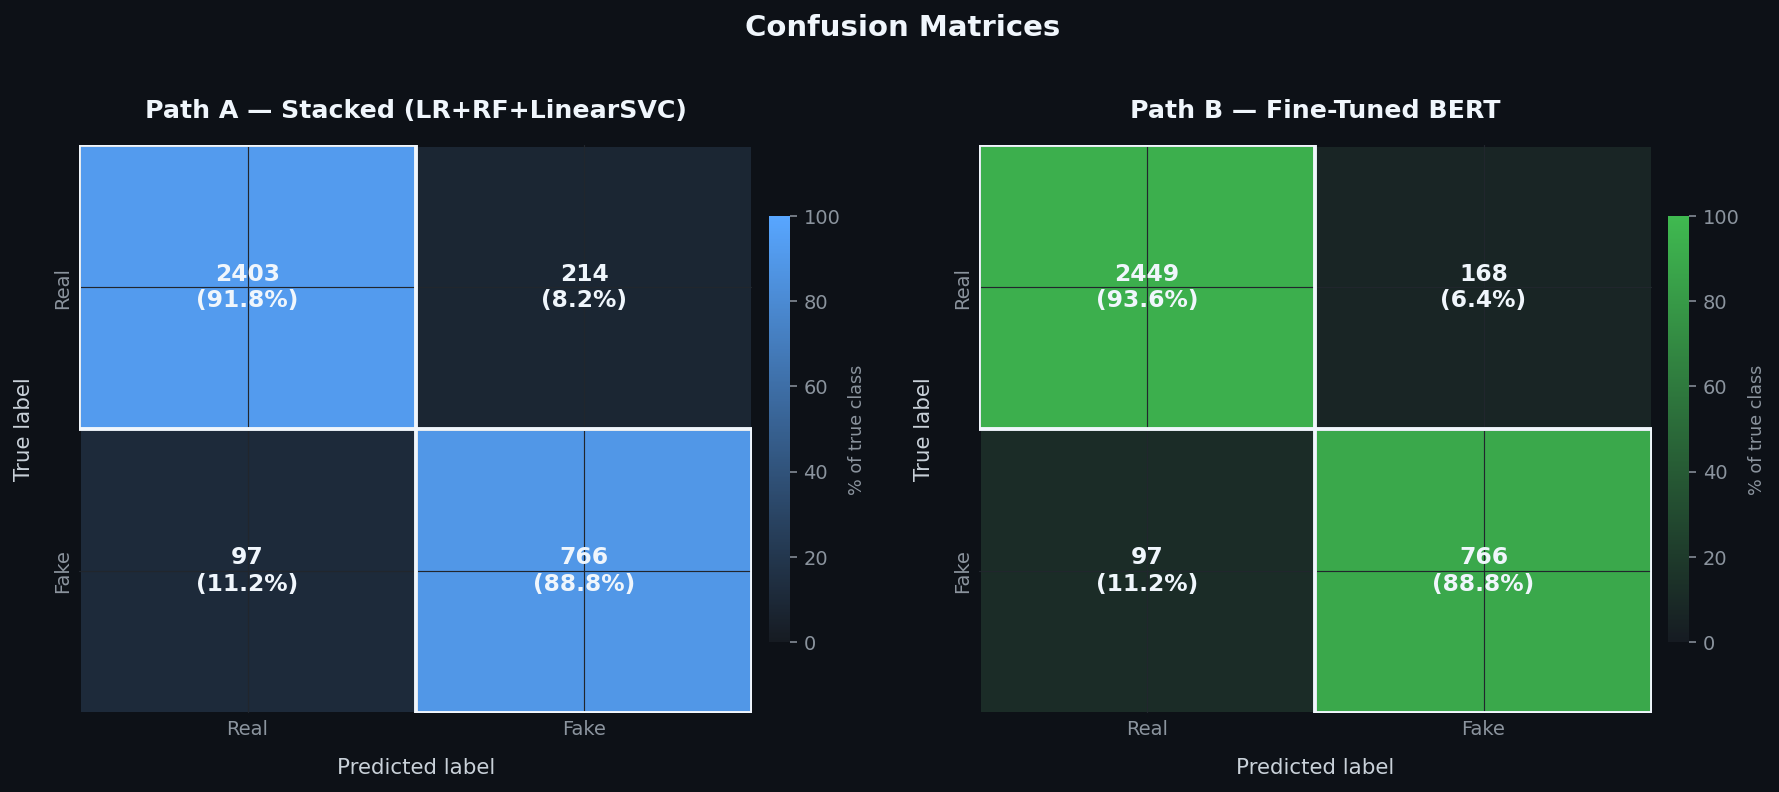

In [17]:
fig, axes = plt.subplots(1,2,figsize=(13,5.5))
fig.suptitle('Confusion Matrices', fontsize=15, color='#F0F6FC', fontweight='bold', y=1.02)
plot_confusion(axes[0], y_test, stack_pred, 'Path A — Stacked (LR+RF+LinearSVC)', C_STACK)
plot_confusion(axes[1], y_test, bert_pred,  'Path B — Fine-Tuned BERT',           C_BERT)
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()

## 7.3 ROC Curves

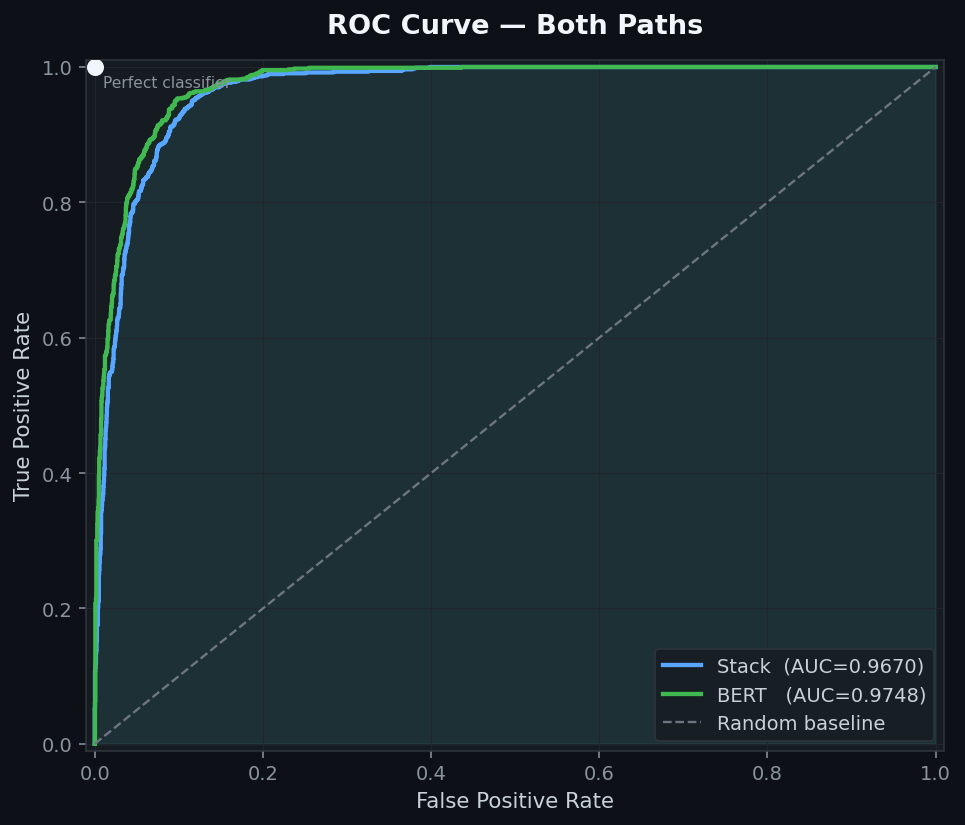

In [18]:
fpr_a,tpr_a,_ = roc_curve(y_test, stack_prob)
fpr_b,tpr_b,_ = roc_curve(y_test, bert_prob)
auc_a = auc(fpr_a,tpr_a)
auc_b = auc(fpr_b,tpr_b)

fig, ax = plt.subplots(figsize=(7,6))
ax.fill_between(fpr_a,tpr_a,alpha=0.08,color=C_STACK)
ax.fill_between(fpr_b,tpr_b,alpha=0.08,color=C_BERT)
ax.plot(fpr_a,tpr_a,color=C_STACK,lw=2.2,label=f'Stack  (AUC={auc_a:.4f})')
ax.plot(fpr_b,tpr_b,color=C_BERT, lw=2.2,label=f'BERT   (AUC={auc_b:.4f})')
ax.plot([0,1],[0,1],'--',color=C_CHANCE,lw=1.2,label='Random baseline')
ax.set_title('ROC Curve — Both Paths',fontsize=14,fontweight='bold',color='#F0F6FC',pad=14)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_xlim([-0.01,1.01]); ax.set_ylim([-0.01,1.01])
ax.legend(loc='lower right')
ax.scatter([0],[1],s=60,color='#F0F6FC',zorder=5)
ax.annotate('Perfect classifier',xy=(0.01,0.97),fontsize=8,color='#8B949E')
plt.tight_layout()
plt.savefig('roc_curves.png',bbox_inches='tight')
plt.show()

## 7.4 Precision-Recall Curves

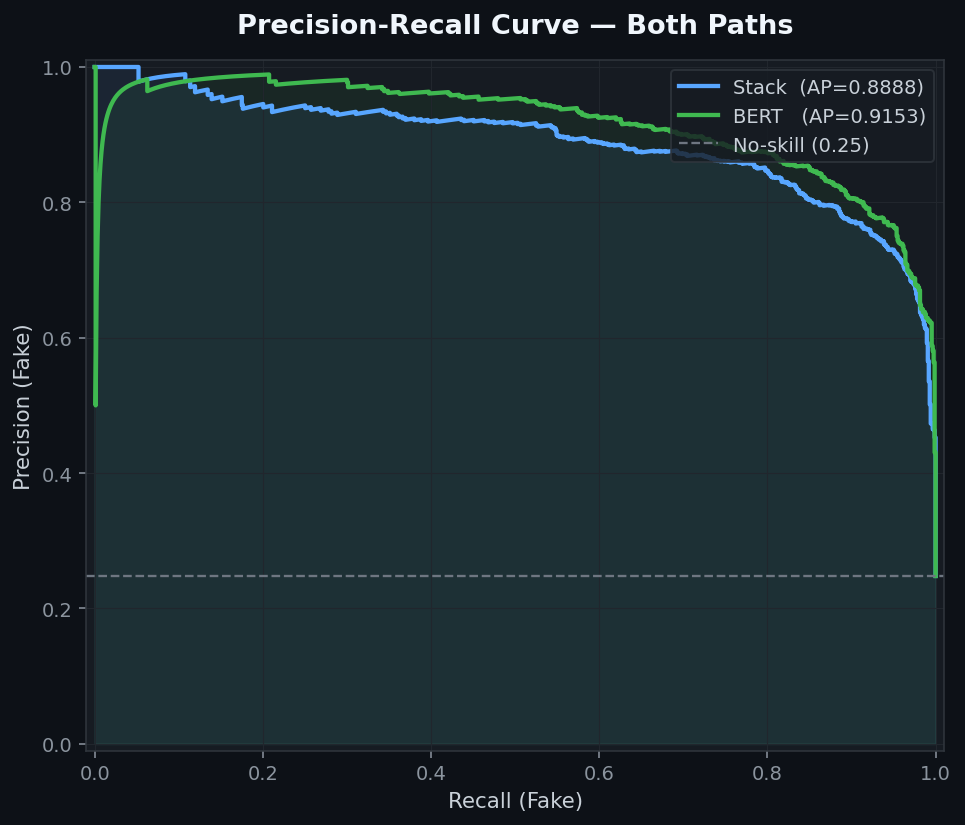

In [19]:
prec_a,rec_a,_ = precision_recall_curve(y_test, stack_prob)
prec_b,rec_b,_ = precision_recall_curve(y_test, bert_prob)
ap_a = average_precision_score(y_test, stack_prob)
ap_b = average_precision_score(y_test, bert_prob)
baseline_pr = y_test.mean()

fig, ax = plt.subplots(figsize=(7,6))
ax.fill_between(rec_a,prec_a,alpha=0.08,color=C_STACK)
ax.fill_between(rec_b,prec_b,alpha=0.08,color=C_BERT)
ax.plot(rec_a,prec_a,color=C_STACK,lw=2.2,label=f'Stack  (AP={ap_a:.4f})')
ax.plot(rec_b,prec_b,color=C_BERT, lw=2.2,label=f'BERT   (AP={ap_b:.4f})')
ax.axhline(baseline_pr,color=C_CHANCE,lw=1.2,ls='--',label=f'No-skill ({baseline_pr:.2f})')
ax.set_title('Precision-Recall Curve — Both Paths',fontsize=14,fontweight='bold',color='#F0F6FC',pad=14)
ax.set_xlabel('Recall (Fake)'); ax.set_ylabel('Precision (Fake)')
ax.set_xlim([-0.01,1.01]); ax.set_ylim([-0.01,1.01])
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('pr_curves.png',bbox_inches='tight')
plt.show()

## 7.5 Threshold Sweep

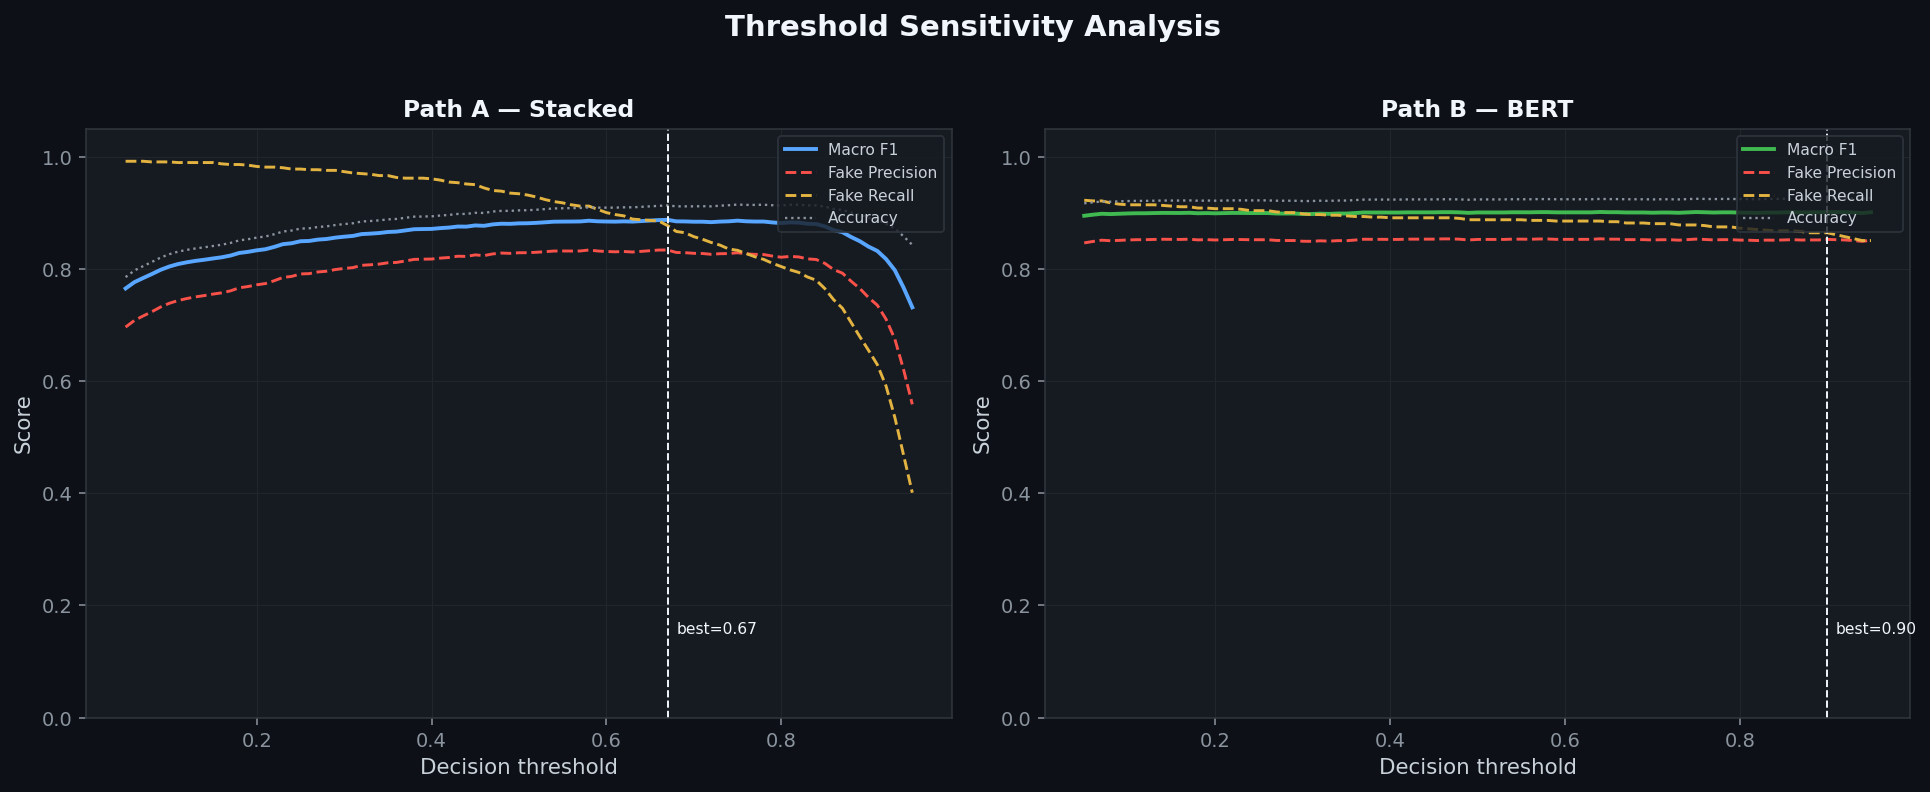

In [20]:
fig, axes = plt.subplots(1,2,figsize=(14,5.5))
fig.suptitle('Threshold Sensitivity Analysis',fontsize=15,color='#F0F6FC',fontweight='bold',y=1.02)
threshold_sweep(y_test,stack_prob,C_STACK,'Path A — Stacked',axes[0])
threshold_sweep(y_test,bert_prob, C_BERT, 'Path B — BERT',   axes[1])
plt.tight_layout()
plt.savefig('threshold_sweep.png',bbox_inches='tight')
plt.show()

## 7.6 Calibration Curves

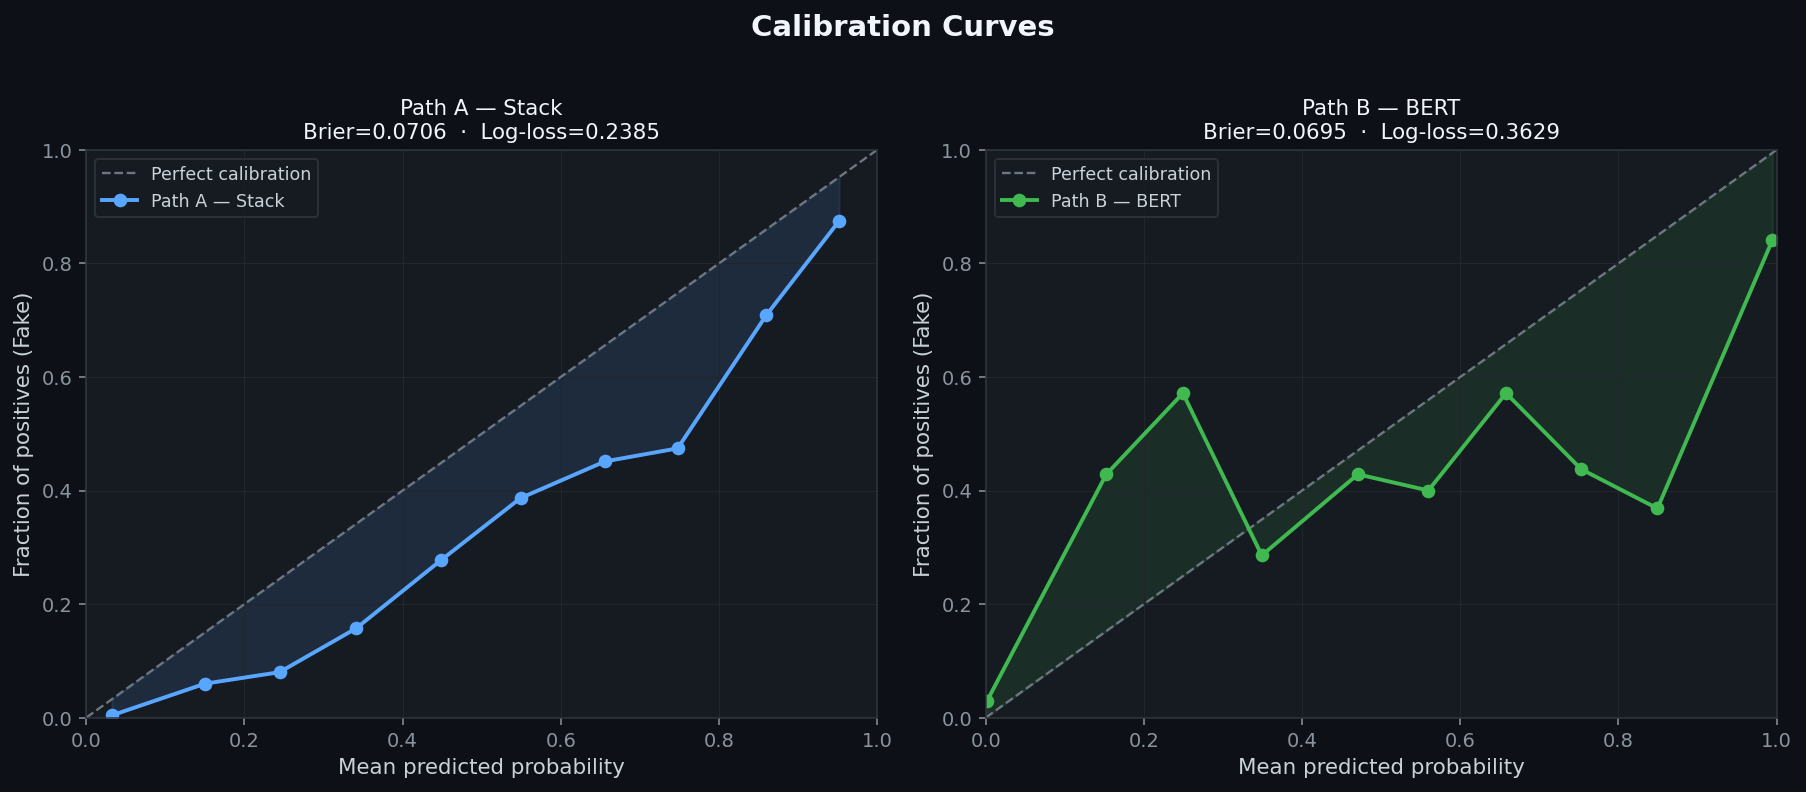

In [21]:
fig, axes = plt.subplots(1,2,figsize=(13,5.5))
fig.suptitle('Calibration Curves',fontsize=15,color='#F0F6FC',fontweight='bold',y=1.02)
for ax,probs,color,label in [
    (axes[0],stack_prob,C_STACK,'Path A — Stack'),
    (axes[1],bert_prob, C_BERT, 'Path B — BERT'),
]:
    fp_,mp_ = calibration_curve(y_test,probs,n_bins=10)
    brier_  = brier_score_loss(y_test,probs)
    ll_     = log_loss(y_test,probs)
    ax.fill_between(mp_,fp_,mp_,alpha=0.12,color=color)
    ax.plot([0,1],[0,1],'--',color=C_CHANCE,lw=1.2,label='Perfect calibration')
    ax.plot(mp_,fp_,'o-',color=color,lw=2,ms=6,label=label)
    ax.set_title(f'{label}\nBrier={brier_:.4f}  ·  Log-loss={ll_:.4f}',fontsize=11,color='#F0F6FC')
    ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Fraction of positives (Fake)')
    ax.set_xlim([0,1]); ax.set_ylim([0,1]); ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('calibration_curves.png',bbox_inches='tight')
plt.show()

## 7.7 Probability Distributions

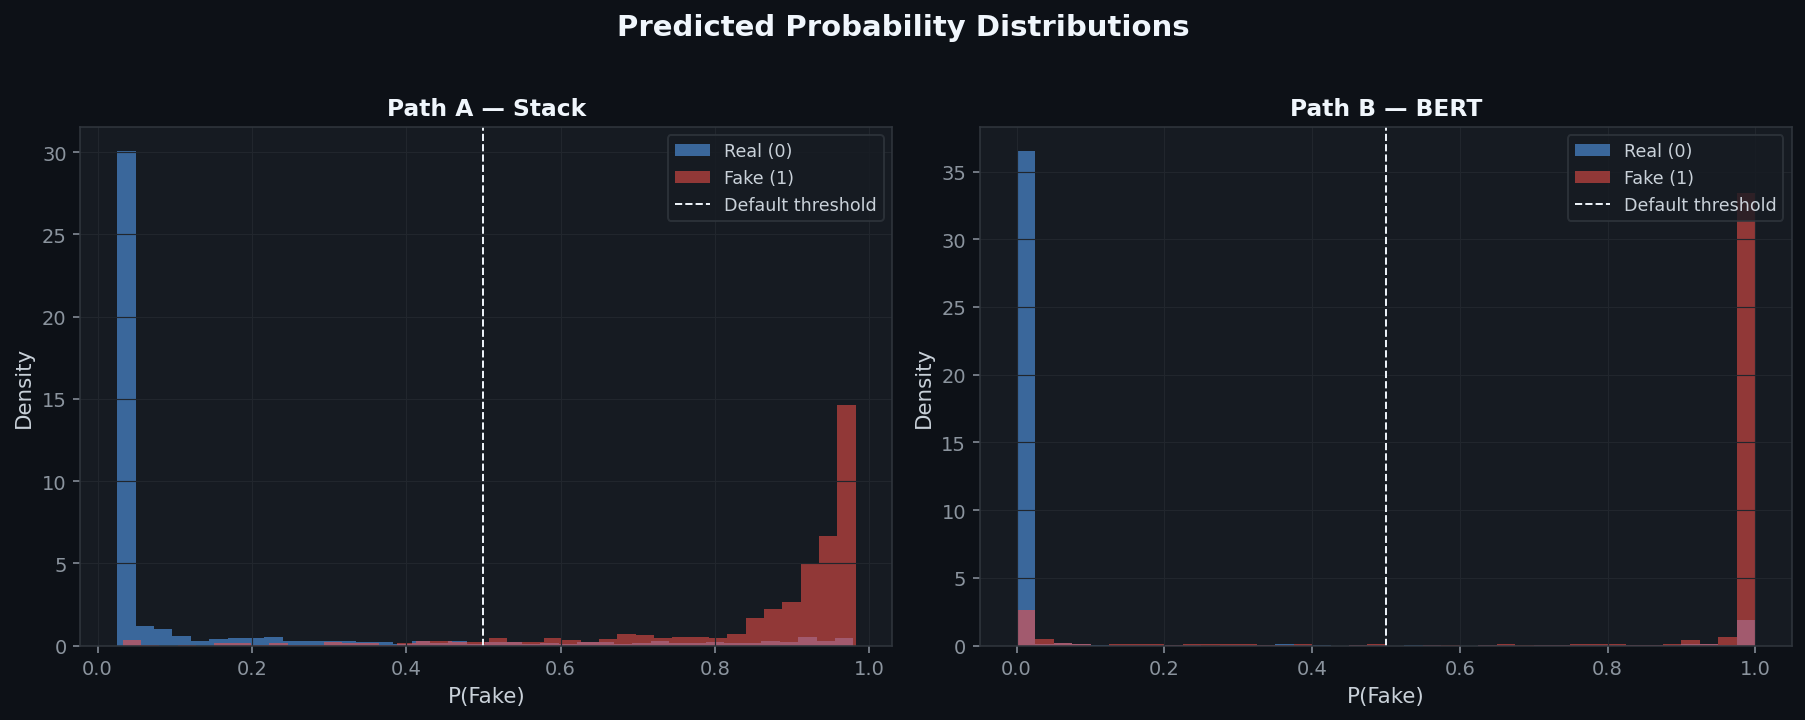

In [22]:
fig, axes = plt.subplots(1,2,figsize=(13,5))
fig.suptitle('Predicted Probability Distributions',fontsize=15,color='#F0F6FC',fontweight='bold',y=1.02)
for ax,probs,label in [(axes[0],stack_prob,'Path A — Stack'),(axes[1],bert_prob,'Path B — BERT')]:
    ax.hist(probs[y_test==0],bins=40,density=True,color=C_REAL,alpha=0.55,label='Real (0)',edgecolor='none')
    ax.hist(probs[y_test==1],bins=40,density=True,color=C_FAKE,alpha=0.55,label='Fake (1)',edgecolor='none')
    ax.axvline(0.5,color='#F0F6FC',lw=1,ls='--',label='Default threshold')
    ax.set_title(label,fontsize=12,color='#F0F6FC',fontweight='bold')
    ax.set_xlabel('P(Fake)'); ax.set_ylabel('Density'); ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('prob_distributions.png',bbox_inches='tight')
plt.show()

## 7.8 Full Metrics Summary + Heatmap


FULL EVALUATION METRICS SUMMARY
Model          Path A — Stack Path B — BERT
Accuracy               0.9106        0.9239
Macro F1               0.8852        0.9006
Weighted F1            0.9124        0.9248
Fake Precision         0.7816        0.8201
Fake Recall            0.8876        0.8876
Fake F1                0.8313        0.8525
Real Precision         0.9612        0.9619
Real Recall            0.9182        0.9358
Real F1                0.9392        0.9487
Specificity            0.9182        0.9358
Sensitivity            0.8876        0.8876
FPR                    0.0818        0.0642
FNR                    0.1124        0.1124
ROC AUC                0.9670        0.9748
Avg Precision          0.8888        0.9153
Brier Score            0.0706        0.0695
Log Loss               0.2385        0.3629
MCC                    0.7737        0.8025
Cohen's Kappa          0.7708        0.8013


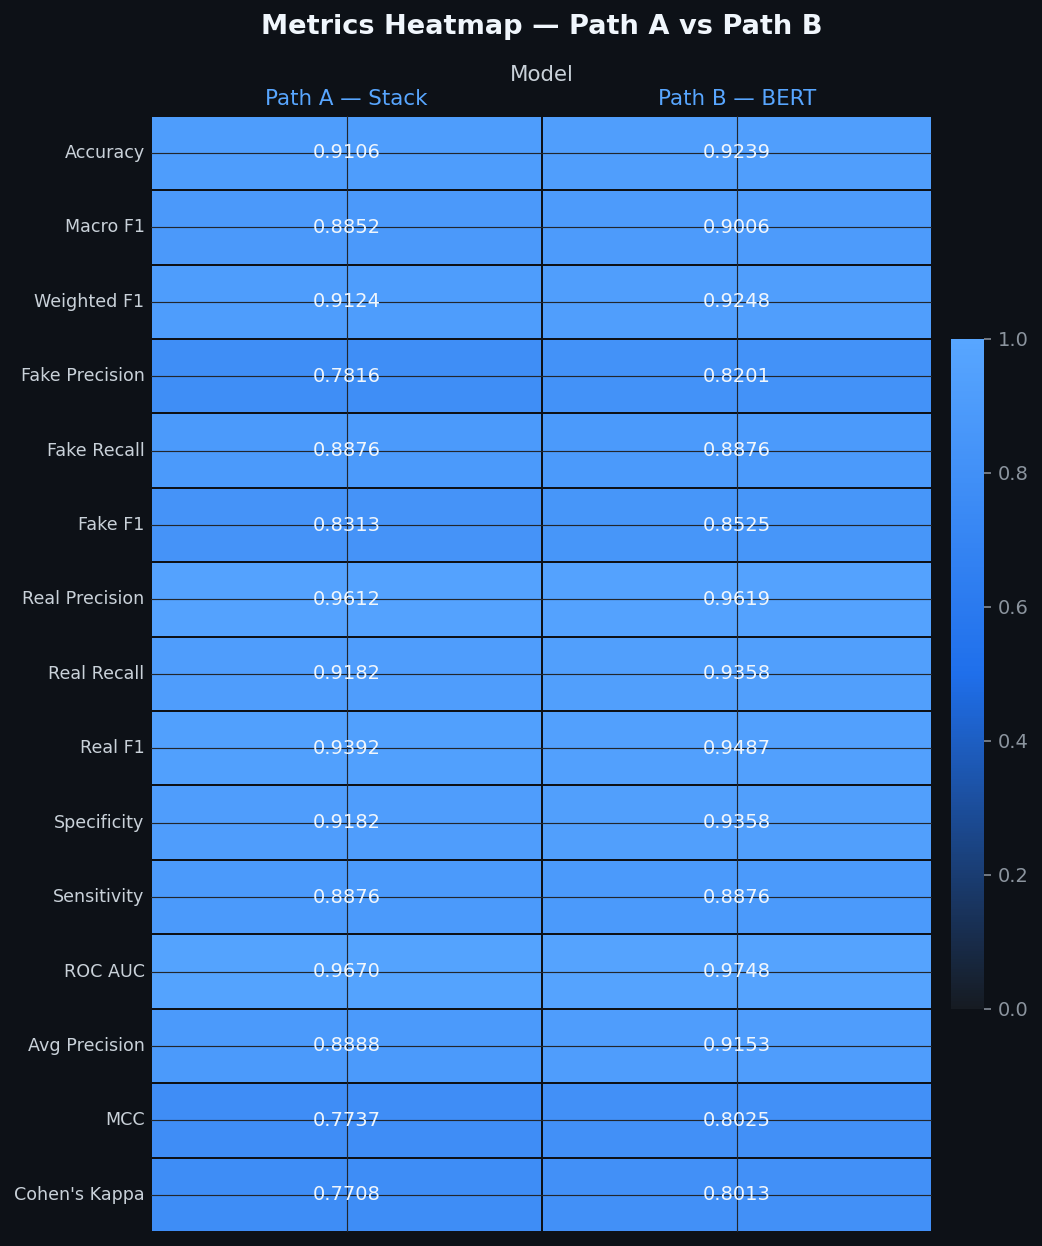

In [23]:
rows = [
    full_metrics(y_test, stack_pred, stack_prob, 'Path A — Stack'),
    full_metrics(y_test, bert_pred,  bert_prob,  'Path B — BERT'),
]
summary = pd.DataFrame(rows).set_index('Model').T
fmt = summary.copy()
for col in fmt.columns:
    fmt[col] = fmt[col].apply(lambda x: f'{x:.4f}')
print('\n','='*60)
print('FULL EVALUATION METRICS SUMMARY')
print('='*60)
print(fmt.to_string())
fmt.to_csv('metrics_summary.csv')

plot_metrics = ['Accuracy','Macro F1','Weighted F1',
                'Fake Precision','Fake Recall','Fake F1',
                'Real Precision','Real Recall','Real F1',
                'Specificity','Sensitivity','ROC AUC',
                'Avg Precision','MCC',"Cohen's Kappa"]
heat_data = summary.loc[plot_metrics].astype(float)

fig, ax = plt.subplots(figsize=(8,9))
cmap = LinearSegmentedColormap.from_list('perf',['#161B22','#1F6FEB','#58A6FF'],N=256)
sns.heatmap(heat_data,annot=True,fmt='.4f',cmap=cmap,
            linewidths=0.8,linecolor='#0D1117',vmin=0,vmax=1,ax=ax,
            annot_kws={'size':10,'color':'#F0F6FC'},
            cbar_kws={'shrink':0.6,'pad':0.02})
ax.set_title('Metrics Heatmap — Path A vs Path B',fontsize=14,fontweight='bold',color='#F0F6FC',pad=16)
ax.tick_params(axis='x',colors='#58A6FF',labelsize=11,length=0)
ax.tick_params(axis='y',colors='#C9D1D9',labelsize=9, length=0)
ax.collections[0].colorbar.ax.tick_params(colors='#8B949E')
ax.xaxis.set_ticks_position('top'); ax.xaxis.set_label_position('top')
plt.tight_layout()
plt.savefig('metrics_heatmap.png',bbox_inches='tight')
plt.show()

## 7.9 Master Dashboard

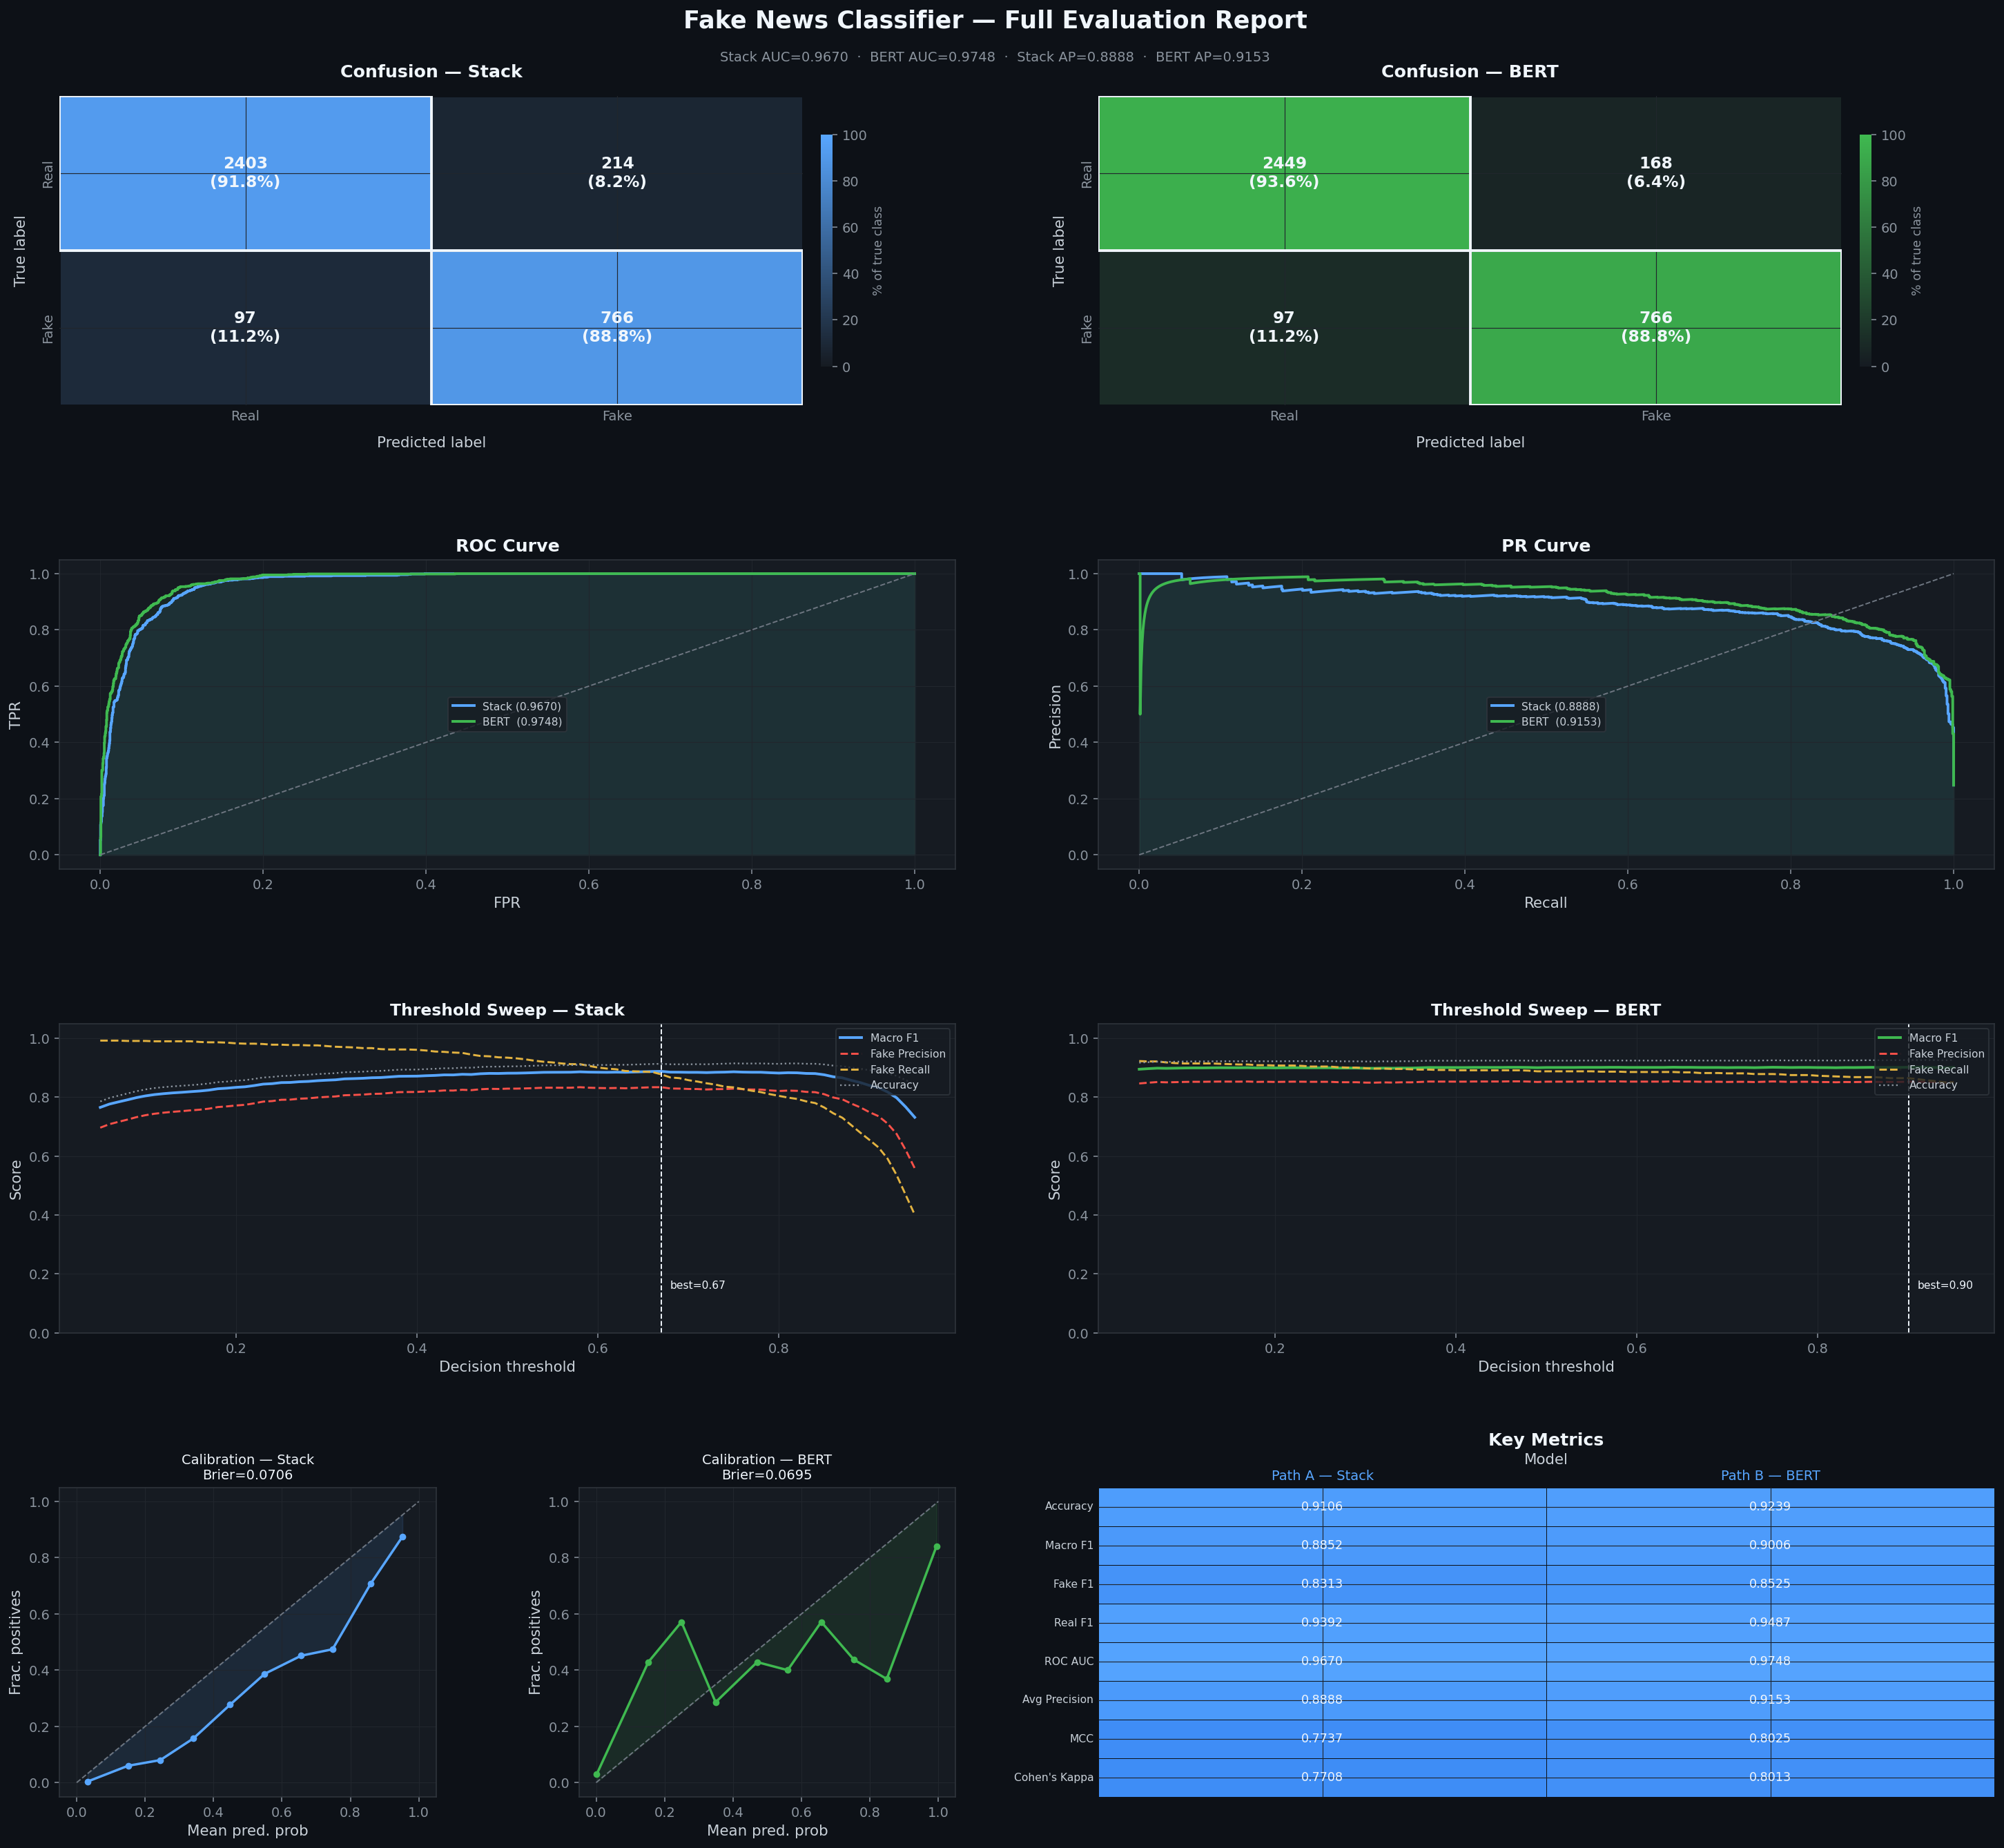

Saved: evaluation_dashboard.png


In [24]:
fig = plt.figure(figsize=(22,20))
fig.patch.set_facecolor('#0D1117')
gs = gridspec.GridSpec(4,4,figure=fig,hspace=0.50,wspace=0.38,
                       top=0.93,bottom=0.05,left=0.06,right=0.97)
fig.text(0.5,0.965,'Fake News Classifier — Full Evaluation Report',
         ha='center',fontsize=18,fontweight='bold',color='#F0F6FC')
fig.text(0.5,0.948,
         f'Stack AUC={auc_a:.4f}  ·  BERT AUC={auc_b:.4f}  '
         f'·  Stack AP={ap_a:.4f}  ·  BERT AP={ap_b:.4f}',
         ha='center',fontsize=10,color='#8B949E')

plot_confusion(fig.add_subplot(gs[0,:2]),y_test,stack_pred,'Confusion — Stack',C_STACK)
plot_confusion(fig.add_subplot(gs[0,2:]),y_test,bert_pred, 'Confusion — BERT', C_BERT)

for ax,(xa,ya),(xb,yb),sa,sb,xl,yl,title in [
    (fig.add_subplot(gs[1,:2]),(fpr_a,tpr_a),(fpr_b,tpr_b),auc_a,auc_b,'FPR','TPR','ROC Curve'),
    (fig.add_subplot(gs[1,2:]),(rec_a,prec_a),(rec_b,prec_b),ap_a,ap_b,'Recall','Precision','PR Curve'),
]:
    ax.fill_between(xa,ya,alpha=0.08,color=C_STACK)
    ax.fill_between(xb,yb,alpha=0.08,color=C_BERT)
    ax.plot(xa,ya,color=C_STACK,lw=2,label=f'Stack ({sa:.4f})')
    ax.plot(xb,yb,color=C_BERT, lw=2,label=f'BERT  ({sb:.4f})')
    ax.plot([0,1],[0,1],'--',color=C_CHANCE,lw=1)
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.set_title(title,color='#F0F6FC',fontweight='bold'); ax.legend(fontsize=8)

threshold_sweep(y_test,stack_prob,C_STACK,'Threshold Sweep — Stack',fig.add_subplot(gs[2,:2]))
threshold_sweep(y_test,bert_prob, C_BERT, 'Threshold Sweep — BERT', fig.add_subplot(gs[2,2:]))

for ax,probs,color,label in [
    (fig.add_subplot(gs[3,0]),stack_prob,C_STACK,'Stack'),
    (fig.add_subplot(gs[3,1]),bert_prob, C_BERT, 'BERT'),
]:
    fp_,mp_ = calibration_curve(y_test,probs,n_bins=10)
    brier_  = brier_score_loss(y_test,probs)
    ax.plot([0,1],[0,1],'--',color=C_CHANCE,lw=1)
    ax.plot(mp_,fp_,'o-',color=color,lw=1.8,ms=4)
    ax.fill_between(mp_,fp_,mp_,alpha=0.1,color=color)
    ax.set_title(f'Calibration — {label}\nBrier={brier_:.4f}',color='#F0F6FC',fontsize=10)
    ax.set_xlabel('Mean pred. prob'); ax.set_ylabel('Frac. positives')

ax_heat = fig.add_subplot(gs[3,2:])
key = ['Accuracy','Macro F1','Fake F1','Real F1','ROC AUC','Avg Precision','MCC',"Cohen's Kappa"]
cmap2 = LinearSegmentedColormap.from_list('perf2',['#161B22','#1F6FEB','#58A6FF'],N=256)
sns.heatmap(heat_data.loc[key],annot=True,fmt='.4f',cmap=cmap2,
            linewidths=0.5,linecolor='#0D1117',vmin=0,vmax=1,ax=ax_heat,
            annot_kws={'size':9,'color':'#F0F6FC'},cbar=False)
ax_heat.set_title('Key Metrics',color='#F0F6FC',fontweight='bold')
ax_heat.tick_params(axis='x',colors='#58A6FF',labelsize=10,length=0)
ax_heat.tick_params(axis='y',colors='#C9D1D9',labelsize=8, length=0)
ax_heat.xaxis.set_ticks_position('top'); ax_heat.xaxis.set_label_position('top')

plt.savefig('evaluation_dashboard.png',dpi=150,bbox_inches='tight')
plt.show()
print('Saved: evaluation_dashboard.png')

## 7.10 Classification Reports + ZIP Export

In [25]:
for name, y_pred in [('Path A — Stack', stack_pred), ('Path B — BERT', bert_pred)]:
    print(f'\n{"="*52}\n  {name}\n{"="*52}')
    print(classification_report(y_test, y_pred, target_names=['Real','Fake'], digits=4))

plots = ['confusion_matrices.png','roc_curves.png','pr_curves.png',
         'threshold_sweep.png','calibration_curves.png','prob_distributions.png',
         'metrics_heatmap.png','evaluation_dashboard.png','metrics_summary.csv']
with zipfile.ZipFile('evaluation_report.zip','w') as zf:
    for f in plots:
        if os.path.exists(f):
            zf.write(f); print(f'  + {f}')
print('\nPacked: evaluation_report.zip')


  Path A — Stack
              precision    recall  f1-score   support

        Real     0.9612    0.9182    0.9392      2617
        Fake     0.7816    0.8876    0.8313       863

    accuracy                         0.9106      3480
   macro avg     0.8714    0.9029    0.8852      3480
weighted avg     0.9167    0.9106    0.9124      3480


  Path B — BERT
              precision    recall  f1-score   support

        Real     0.9619    0.9358    0.9487      2617
        Fake     0.8201    0.8876    0.8525       863

    accuracy                         0.9239      3480
   macro avg     0.8910    0.9117    0.9006      3480
weighted avg     0.9267    0.9239    0.9248      3480

  + confusion_matrices.png
  + roc_curves.png
  + pr_curves.png
  + threshold_sweep.png
  + calibration_curves.png
  + prob_distributions.png
  + metrics_heatmap.png
  + evaluation_dashboard.png
  + metrics_summary.csv

Packed: evaluation_report.zip


---
# 8. Inference — Single Input → Two Outputs

In [26]:
def predict(text: str) -> dict:
    clean_text = re.sub(r'[^a-zA-Z ]',' ', text.lower())
    clean_text = re.sub(r'\s+',' ', clean_text).strip()

    # PATH A — Stack
    vec     = tfidf.transform([clean_text])
    p_lr    = lr.predict_proba(vec)[0,1]
    p_rf    = rf.predict_proba(vec)[0,1]
    p_svm   = svm.predict_proba(vec)[0,1]
    p_stack = meta_stack.predict_proba([[p_lr,p_rf,p_svm]])[0,1]
    out_a   = 'FAKE' if p_stack >= best_thresh_a else 'REAL'

    # PATH B — Fine-tuned BERT
    bert_model.eval()
    enc = tokenizer(clean_text, truncation=True, padding='max_length',
                    max_length=MAX_LEN, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        logits = bert_model(**enc).logits
    p_bert = torch.softmax(logits, dim=1)[0,1].item()
    out_b  = 'FAKE' if p_bert >= best_thresh_b else 'REAL'

    return {
        'Output A — Stack': {
            'LR prob'   : round(p_lr,   3),
            'RF prob'   : round(p_rf,   3),
            'SVM prob'  : round(p_svm,  3),
            'Final prob': round(p_stack,3),
            'Threshold' : round(best_thresh_a,2),
            'Prediction': out_a,
        },
        'Output B — BERT (fine-tuned)': {
            'BERT prob' : round(p_bert,3),
            'Threshold' : round(best_thresh_b,2),
            'Prediction': out_b,
        }
    }


sample = 'Scientists confirm that drinking water cures all known diseases'
result = predict(sample)
print(f'Input: "{sample}"\n')
for path, details in result.items():
    print(path)
    for k,v in details.items():
        print(f'  {k}: {v}')
    print()

Input: "Scientists confirm that drinking water cures all known diseases"

Output A — Stack
  LR prob: 0.876
  RF prob: 0.653
  SVM prob: 0.876
  Final prob: 0.892
  Threshold: 0.64
  Prediction: FAKE

Output B — BERT (fine-tuned)
  BERT prob: 0.868
  Threshold: 0.51
  Prediction: FAKE



In [28]:
import zipfile, os, json

# Save BERT tokenizer + model (already in notebook)
bert_model.save_pretrained('bert_finetuned')
tokenizer.save_pretrained('bert_finetuned')

# Save thresholds + metadata
meta = {
    'thresh_a'     : float(best_thresh_a),
    'thresh_b'     : float(best_thresh_b),
    'bert_val_f1'  : float(best_val_f1),
    'stack_auc'    : float(auc_a),
    'bert_auc'     : float(auc_b),
    'dataset_rows' : len(df),
    'fake_count'   : int(sum(y)),
    'real_count'   : int(len(y)-sum(y)),
}
with open('model_metadata.json','w') as f:
    json.dump(meta, f, indent=2)

# Pack everything
with zipfile.ZipFile('fake_news_complete_save.zip','w') as zf:
    # Models
    for f in ['tfidf_vectorizer.pkl','model_lr.pkl','model_rf.pkl',
              'model_svm.pkl','model_meta_stack.pkl','thresholds.pkl',
              'model_metadata.json']:
        if os.path.exists(f): zf.write(f); print(f'+ {f}')
    # BERT folder
    for root, dirs, files in os.walk('bert_finetuned'):
        for file in files:
            fp = os.path.join(root, file)
            zf.write(fp); print(f'+ {fp}')
    # Evaluation plots
    for f in ['confusion_matrices.png','roc_curves.png','pr_curves.png',
              'threshold_sweep.png','calibration_curves.png',
              'prob_distributions.png','metrics_heatmap.png',
              'evaluation_dashboard.png','metrics_summary.csv']:
        if os.path.exists(f): zf.write(f); print(f'+ {f}')

print('\nEverything saved to: fake_news_complete_save.zip')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

+ tfidf_vectorizer.pkl
+ model_lr.pkl
+ model_rf.pkl
+ model_svm.pkl
+ model_meta_stack.pkl
+ thresholds.pkl
+ model_metadata.json
+ bert_finetuned/config.json
+ bert_finetuned/model.safetensors
+ bert_finetuned/tokenizer.json
+ bert_finetuned/tokenizer_config.json
+ confusion_matrices.png
+ roc_curves.png
+ pr_curves.png
+ threshold_sweep.png
+ calibration_curves.png
+ prob_distributions.png
+ metrics_heatmap.png
+ evaluation_dashboard.png
+ metrics_summary.csv

Everything saved to: fake_news_complete_save.zip


In [29]:
from google.colab import files
files.download('fake_news_complete_save.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
import joblib, torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Classical models
tfidf      = joblib.load('tfidf_vectorizer.pkl')
lr         = joblib.load('model_lr.pkl')
rf         = joblib.load('model_rf.pkl')
svm        = joblib.load('model_svm.pkl')
meta_stack = joblib.load('model_meta_stack.pkl')
thresh     = joblib.load('thresholds.pkl')
best_thresh_a = thresh['thresh_a']
best_thresh_b = thresh['thresh_b']

# BERT
tokenizer  = AutoTokenizer.from_pretrained('bert_finetuned')
bert_model = AutoModelForSequenceClassification.from_pretrained('bert_finetuned').to(DEVICE)
bert_model.eval()
print('All models loaded.')

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

All models loaded.


In [31]:
# Obvious fake
predict("Government confirms chemtrails are mind control experiments")

# Subtle fake (harder)
predict("New study shows coffee causes cancer in 90% of users")

# Real news style
predict("Federal Reserve holds interest rates steady amid inflation concerns")

{'Output A — Stack': {'LR prob': np.float64(0.868),
  'RF prob': np.float64(0.738),
  'SVM prob': np.float64(0.834),
  'Final prob': np.float64(0.92),
  'Threshold': np.float64(0.64),
  'Prediction': 'FAKE'},
 'Output B — BERT (fine-tuned)': {'BERT prob': 0.002,
  'Threshold': np.float64(0.51),
  'Prediction': 'REAL'}}

In [32]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [35]:
import os

path = '/content/drive/MyDrive/FakeNewsProject/'
os.makedirs(path, exist_ok=True)

print("✅ Folder created")

✅ Folder created


In [37]:
!cp model_meta_stack.pkl /content/drive/MyDrive/FakeNewsProject/model.pkl
!cp tfidf_vectorizer.pkl /content/drive/MyDrive/FakeNewsProject/tfidf.pkl

In [38]:
!ls /content/drive/MyDrive/FakeNewsProject/

model.pkl  tfidf.pkl


In [40]:
from google.colab import files

files.download('/content/drive/MyDrive/FakeNewsProject/model.pkl')
files.download('/content/drive/MyDrive/FakeNewsProject/tfidf.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>